In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pymannkendall as mk
import numpy as np
from scipy import stats

In [2]:
results_df = pd.read_csv(
    "../outputs/method1_results.csv",
    parse_dates=["fire_year_start", "first_ignition_date", "last_ignition_date", "last_extinction_date"]
)
method2_df = pd.read_csv("../outputs/method2_results.csv", parse_dates=["fire_year_start", "p5_date", "p95_date"])

print(results_df.shape)
print(method2_df.shape)

df_results = pd.read_csv("../outputs/method3_percell_results.csv")
df_results = df_results.set_index("fire_year")
print(df_results.shape)
df_results.head()

(24, 9)
(24, 6)
(21, 8)


,fsl_p90_median,fsl_p95_median,p90_cell_coverage,p95_cell_coverage,start_doy_p90,end_doy_p90,start_doy_p95,end_doy_p95
fire_year,,,,,,,,
2002-2003,40.0,31.5,0.775510,0.367347,216.5,248.0,212.0,243.0
2003-2004,16.0,3.5,0.795918,0.408163,218.0,230.0,219.0,228.0
2004-2005,12.5,3.0,0.857143,0.510204,201.0,241.0,239.0,241.0
2005-2006,4.0,3.0,0.714286,0.081633,223.0,227.0,225.5,228.0
2006-2007,3.0,4.0,0.367347,0.061224,196.0,208.5,196.0,199.0


In [3]:
results_df["fire_year"] = results_df["fire_year_start"].dt.year.astype(str) + "-" + (results_df["fire_year_start"].dt.year + 1).astype(str)
method2_df["fire_year"] = method2_df["fire_year_start"].dt.year.astype(str) + "-" + (method2_df["fire_year_start"].dt.year + 1).astype(str)
valid_years = df_results.index.tolist()
m1_trimmed = results_df[results_df["fire_year"].isin(valid_years)][["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method1_days"})
m2_trimmed = method2_df[method2_df["fire_year"].isin(valid_years)][["fire_year", "season_length_days"]].rename(columns={"season_length_days": "method2_days"})
m3_trimmed = df_results.reset_index()[["fire_year", "fsl_p90_median"]].rename(columns={"fsl_p90_median": "method3_days"})
print(f"Method 1 trimmed: {len(m1_trimmed)} years")
print(f"Method 2 trimmed: {len(m2_trimmed)} years")
print(f"Method 3: {len(m3_trimmed)} years")
comparison_df = m1_trimmed.merge(m2_trimmed, on="fire_year").merge(m3_trimmed, on="fire_year")
comparison_df = comparison_df.sort_values("fire_year").reset_index(drop=True)
comparison_df

# summary stats for each method
summary_stats = pd.DataFrame({
    "method1_days": comparison_df["method1_days"],
    "method2_days": comparison_df["method2_days"],
    "method3_days": comparison_df["method3_days"],
}).agg(["sum", "mean", "min", "max"]).T

summary_stats["range"] = summary_stats["max"] - summary_stats["min"]
summary_stats = summary_stats.rename(columns={"sum": "total", "mean": "average"})
summary_stats = summary_stats.round(2)

print(summary_stats)

Method 1 trimmed: 21 years
Method 2 trimmed: 21 years
Method 3: 21 years
               total  average    min    max  range
method1_days  6435.0   306.43  236.0  385.0  149.0
method2_days  1809.0    86.14    7.0  224.0  217.0
method3_days   733.5    34.93    3.0   86.0   83.0


In [4]:
# Figure Aesthetics
method_colors = {
    "method1": "#5B7FBF",  
    "method2": "#F77F00", 
    "method3": "#43AA8B",  
}

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

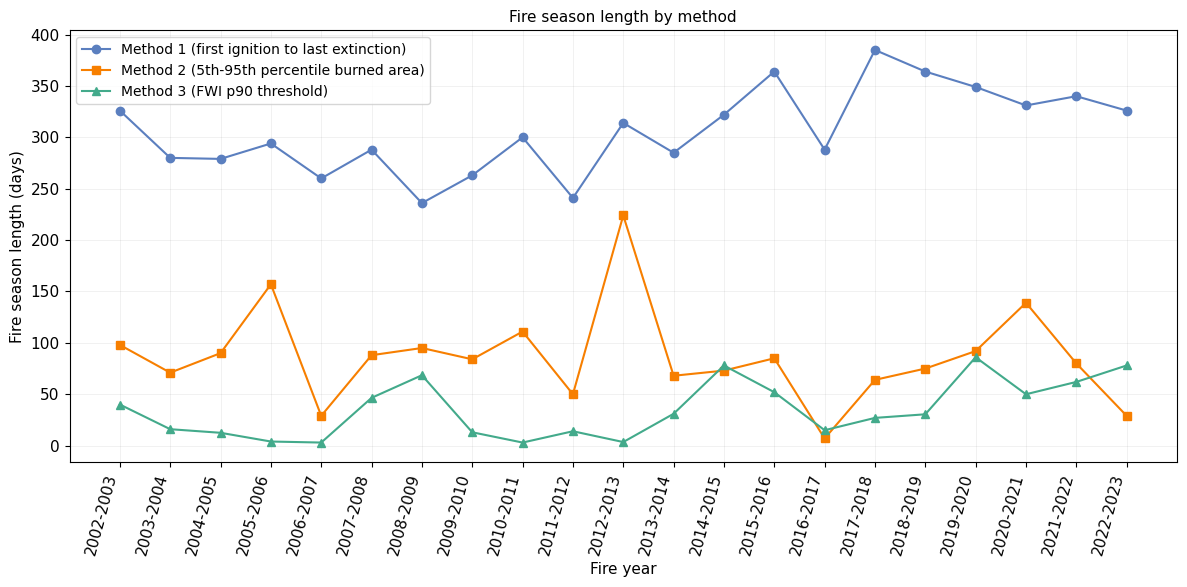

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(comparison_df["fire_year"], comparison_df["method1_days"], marker="o",
        color=method_colors["method1"], label="Method 1 (first ignition to last extinction)")
ax.plot(comparison_df["fire_year"], comparison_df["method2_days"], marker="s",
        color=method_colors["method2"], label="Method 2 (5th-95th percentile burned area)")
ax.plot(comparison_df["fire_year"], comparison_df["method3_days"], marker="^",
        color=method_colors["method3"], label="Method 3 (FWI p90 threshold)")
ax.set_xlabel("Fire year")
ax.set_ylabel("Fire season length (days)")
ax.set_title("Fire season length by method")
ax.legend()
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
plt.show()
fig.savefig("../outputs/fsl_3_methods.png", dpi=400, bbox_inches="tight")

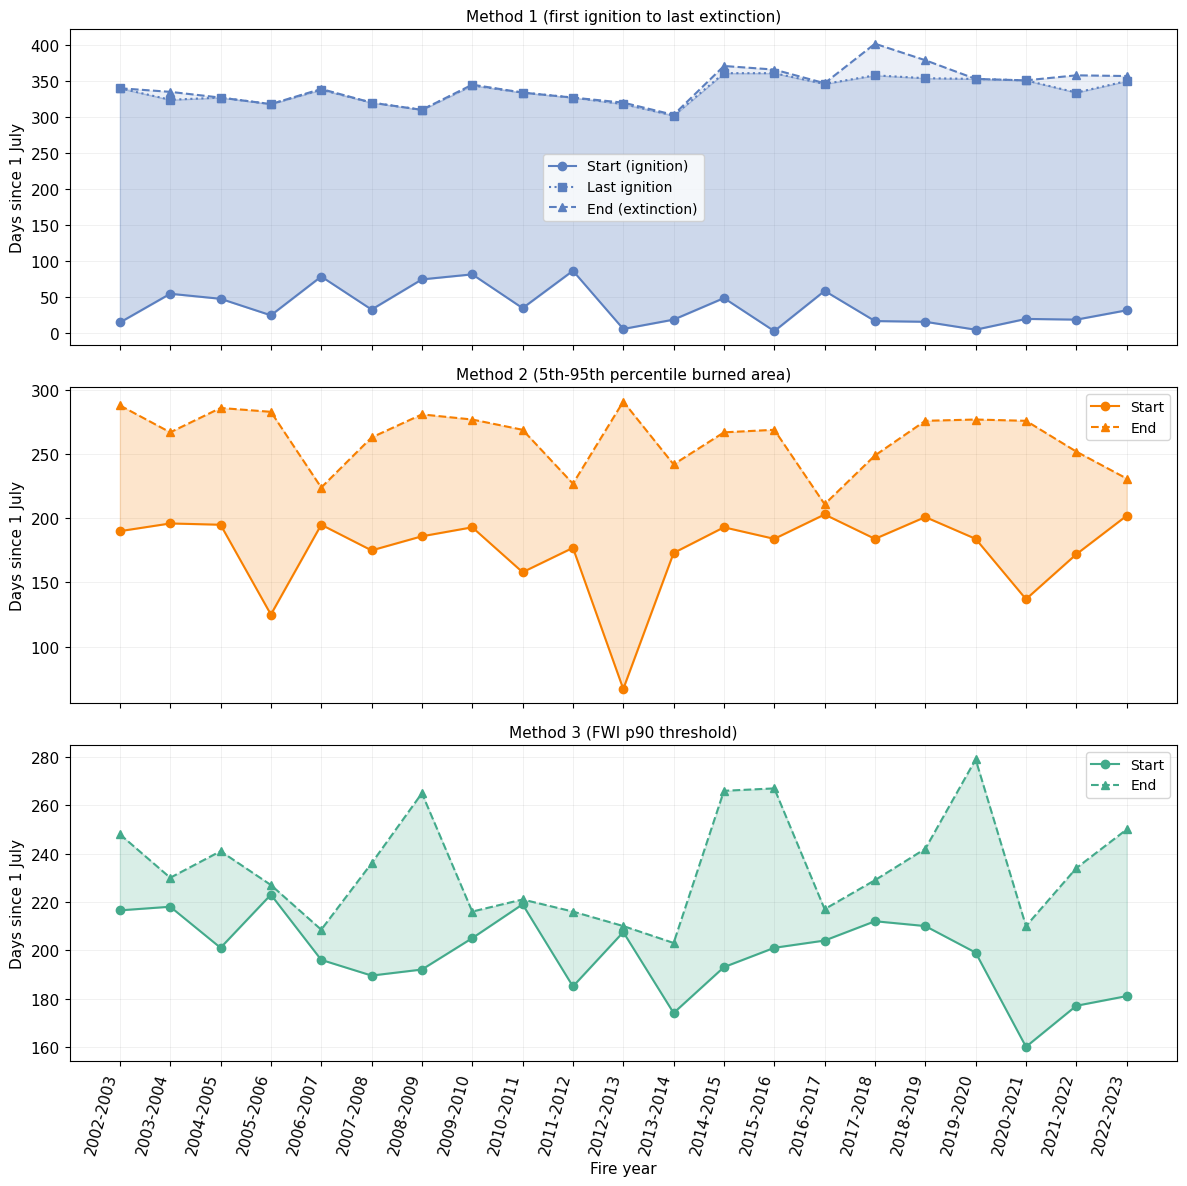

In [6]:
# Compute day-of-season for Method 1 and Method 2
results_df["first_day"] = (results_df["first_ignition_date"] - results_df["fire_year_start"]).dt.days
results_df["last_ignition_day"] = (results_df["last_ignition_date"] - results_df["fire_year_start"]).dt.days
results_df["last_day"] = (results_df["last_extinction_date"] - results_df["fire_year_start"]).dt.days
method2_df["first_day"] = (method2_df["p5_date"] - method2_df["fire_year_start"]).dt.days
method2_df["last_day"] = (method2_df["p95_date"] - method2_df["fire_year_start"]).dt.days
m1_dates = results_df[results_df["fire_year"].isin(valid_years)][["fire_year", "first_day", "last_ignition_day", "last_day"]]
m2_dates = method2_df[method2_df["fire_year"].isin(valid_years)][["fire_year", "first_day", "last_day"]]
m3_dates = df_results.reset_index()[["fire_year", "start_doy_p90", "end_doy_p90"]].rename(
    columns={"start_doy_p90": "first_day", "end_doy_p90": "last_day"})
m1_dates = m1_dates.sort_values("fire_year").reset_index(drop=True)
m2_dates = m2_dates.sort_values("fire_year").reset_index(drop=True)
m3_dates = m3_dates.sort_values("fire_year").reset_index(drop=True)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
panel_data = [
    (m1_dates, "Method 1 (first ignition to last extinction)", method_colors["method1"]),
    (m2_dates, "Method 2 (5th-95th percentile burned area)", method_colors["method2"]),
    (m3_dates, "Method 3 (FWI p90 threshold)", method_colors["method3"]),
]
for i, (ax, (data, title, color)) in enumerate(zip(axes, panel_data)):
    if i == 0:
        # Method 1: show ignition window and extinction tail separately
        ax.plot(data["fire_year"], data["first_day"], marker="o", linestyle="-", color=color, label="Start (ignition)")
        ax.plot(data["fire_year"], data["last_ignition_day"], marker="s", linestyle=":", color=color, label="Last ignition")
        ax.plot(data["fire_year"], data["last_day"], marker="^", linestyle="--", color=color, label="End (extinction)")
        ax.fill_between(data["fire_year"], data["first_day"], data["last_ignition_day"], color=color, alpha=0.3)
        ax.fill_between(data["fire_year"], data["last_ignition_day"], data["last_day"], color=color, alpha=0.12)
    else:
        ax.plot(data["fire_year"], data["first_day"], marker="o", linestyle="-", color=color, label="Start")
        ax.plot(data["fire_year"], data["last_day"], marker="^", linestyle="--", color=color, label="End")
        ax.fill_between(data["fire_year"], data["first_day"], data["last_day"], color=color, alpha=0.2)
    ax.set_ylabel("Days since 1 July")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
    ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it
axes[-1].set_xlabel("Fire year")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fsl_3_panel.png", dpi=400, bbox_inches="tight")

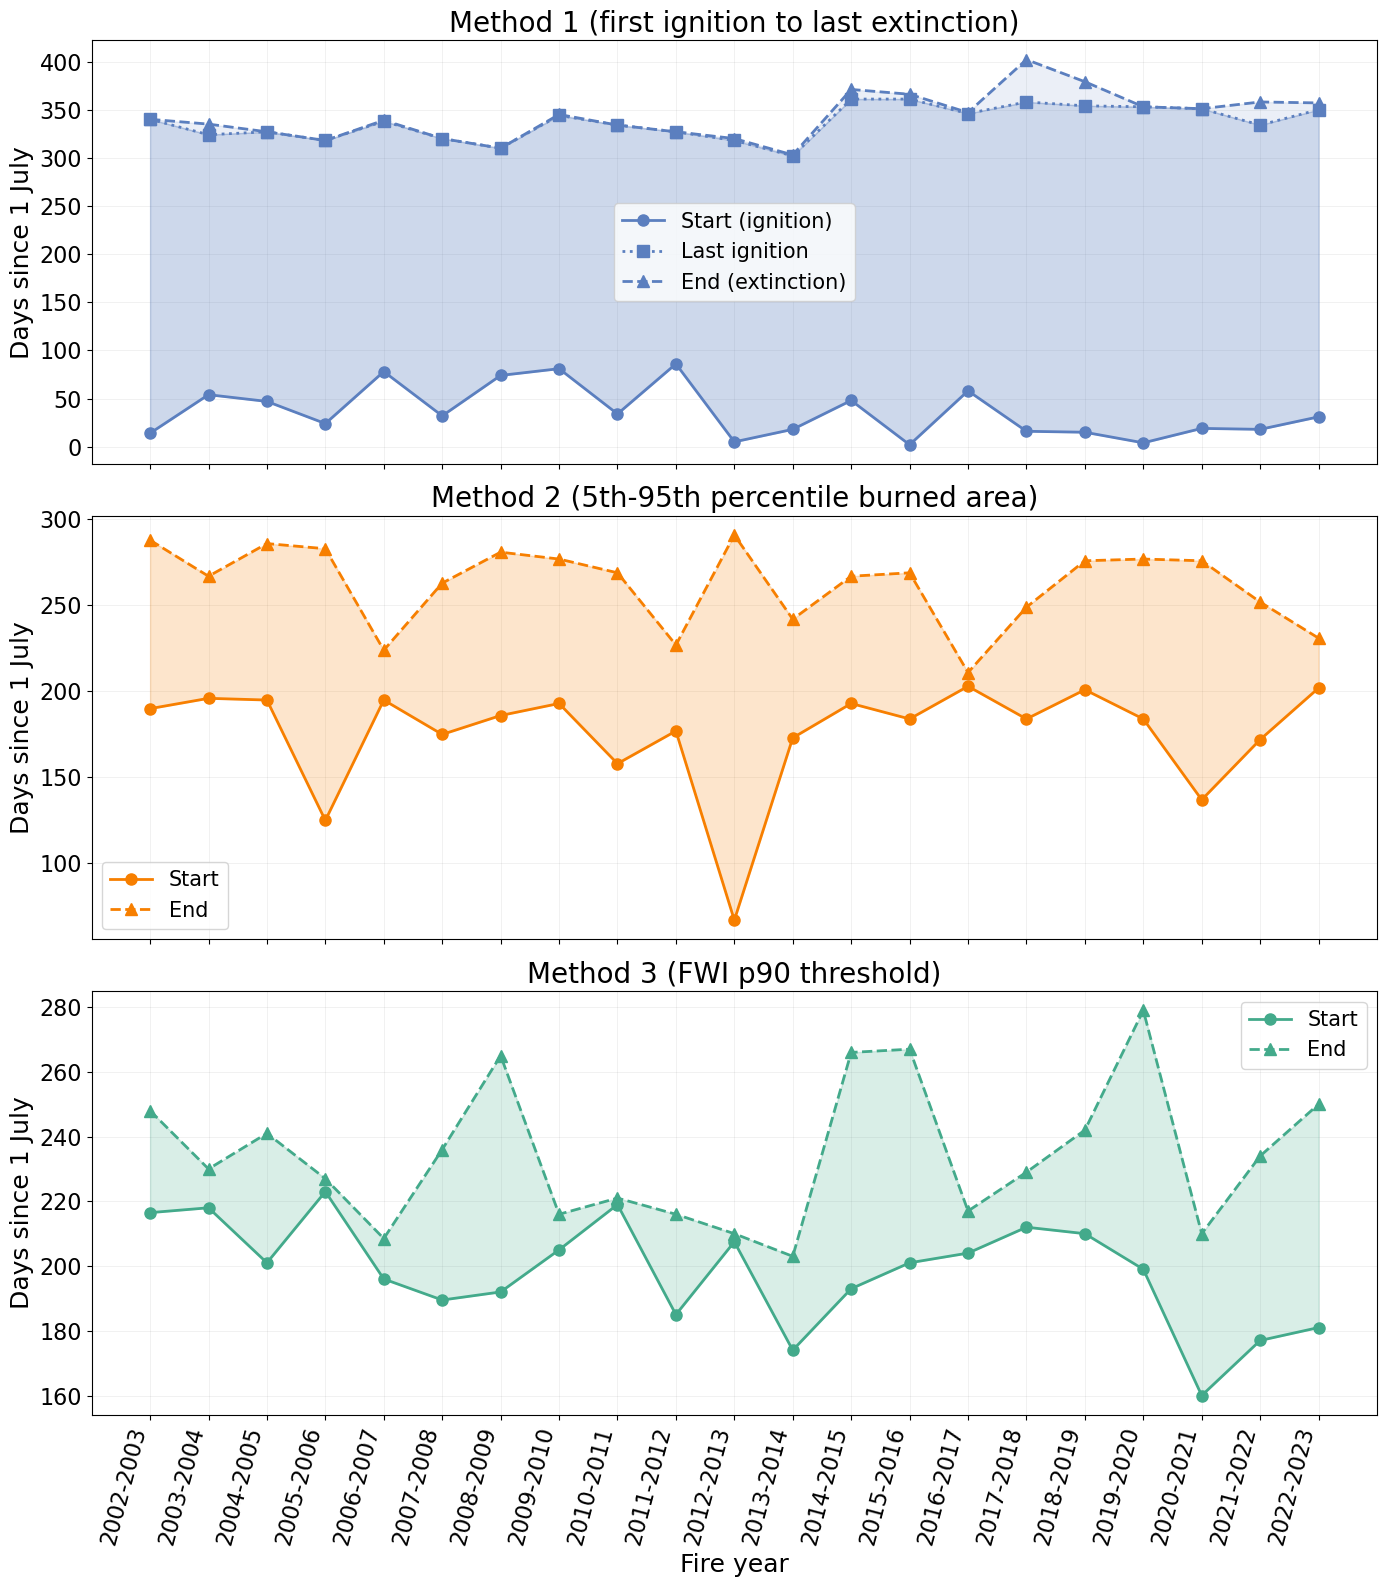

In [7]:
# Poster version of the FSL 3-panel figure (larger fonts, same data and logic)
poster_fontsize = {
    "title": 20,
    "label": 18,
    "tick": 16,
    "legend": 15,
}

fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

for i, (ax, (data, title, color)) in enumerate(zip(axes, panel_data)):
    if i == 0:
        # Method 1: show ignition window and extinction tail separately
        ax.plot(data["fire_year"], data["first_day"], marker="o", linestyle="-", color=color, label="Start (ignition)", markersize=8, linewidth=2)
        ax.plot(data["fire_year"], data["last_ignition_day"], marker="s", linestyle=":", color=color, label="Last ignition", markersize=8, linewidth=2)
        ax.plot(data["fire_year"], data["last_day"], marker="^", linestyle="--", color=color, label="End (extinction)", markersize=8, linewidth=2)
        ax.fill_between(data["fire_year"], data["first_day"], data["last_ignition_day"], color=color, alpha=0.3)
        ax.fill_between(data["fire_year"], data["last_ignition_day"], data["last_day"], color=color, alpha=0.12)
    else:
        ax.plot(data["fire_year"], data["first_day"], marker="o", linestyle="-", color=color, label="Start", markersize=8, linewidth=2)
        ax.plot(data["fire_year"], data["last_day"], marker="^", linestyle="--", color=color, label="End", markersize=8, linewidth=2)
        ax.fill_between(data["fire_year"], data["first_day"], data["last_day"], color=color, alpha=0.2)
    ax.set_ylabel("Days since 1 July", fontsize=poster_fontsize["label"])
    ax.set_title(title, fontsize=poster_fontsize["title"])
    ax.legend(fontsize=poster_fontsize["legend"])
    ax.tick_params(axis='both', labelsize=poster_fontsize["tick"])
    ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
    ax.set_axisbelow(True)  # ensures grid sits behind the data, not on top of it

axes[-1].set_xlabel("Fire year", fontsize=poster_fontsize["label"])
plt.xticks(rotation=75, ha="right", fontsize=poster_fontsize["tick"])
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fsl_3_panel_poster.png", dpi=400, bbox_inches="tight")

## Statistical Comparison (start and end dates) 

In [8]:
method_datasets = {
    "Method 1 (first-last fire date)": m1_dates,
    "Method 2 (5th-95th percentile burned area)": m2_dates,
    "Method 3 (FWI p90 threshold)": m3_dates,
}

start_end_results = []

for method_name, data in method_datasets.items():
    data_sorted = data.sort_values("fire_year").reset_index(drop=True)

    mk_start = mk.original_test(data_sorted["first_day"])
    mk_end = mk.original_test(data_sorted["last_day"])

    start_end_results.append({
        "method": method_name,
        "variable": "Start date",
        "trend": mk_start.trend,
        "p_value": round(mk_start.p, 4),
        "sen_slope_days_per_year": round(mk_start.slope, 3),
        "tau": round(mk_start.Tau, 3),
    })
    start_end_results.append({
        "method": method_name,
        "variable": "End date",
        "trend": mk_end.trend,
        "p_value": round(mk_end.p, 4),
        "sen_slope_days_per_year": round(mk_end.slope, 3),
        "tau": round(mk_end.Tau, 3),
    })

start_end_trend_df = pd.DataFrame(start_end_results)
start_end_trend_df

,method,variable,trend,p_value,sen_slope_days_per_year,tau
0,Method 1 (first-last fire date),Start date,no trend,0.1838,-1.442,-0.214
1,Method 1 (first-last fire date),End date,increasing,0.0234,1.870,0.362
2,Method 2 (5th-95th percentile burned area),Start date,no trend,0.8086,-0.174,-0.043
3,Method 2 (5th-95th percentile burned area),End date,no trend,0.1382,-1.236,-0.238
4,Method 3 (FWI p90 threshold),Start date,no trend,0.0611,-1.177,-0.300
5,Method 3 (FWI p90 threshold),End date,no trend,0.6944,0.183,0.067


## Statistical Comparison

In [9]:
for method_col, method_name in [("method1_days", "Method 1"), ("method2_days", "Method 2"), ("method3_days", "Method 3")]:
    data = comparison_df[method_col].dropna()
    result = mk.original_test(data)
    print(f"{method_name}: trend={result.trend}, p={result.p:.4f}, Sen's slope={result.slope:.3f} days/year")

Method 1: trend=increasing, p=0.0111, Sen's slope=3.612 days/year
Method 2: trend=no trend, p=0.3648, Sen's slope=-1.000 days/year
Method 3: trend=increasing, p=0.0200, Sen's slope=2.174 days/year


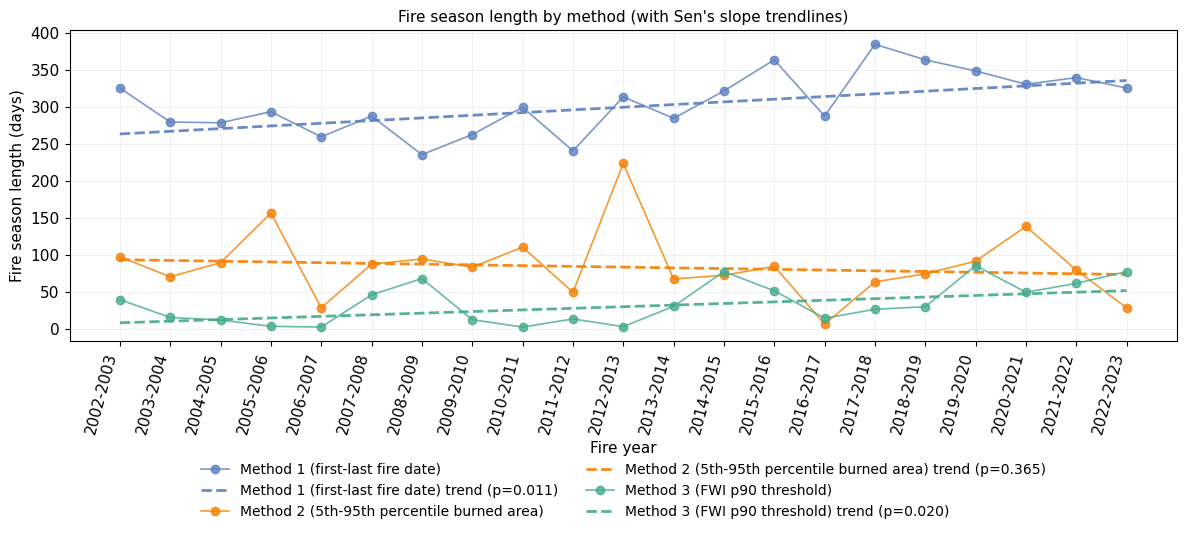

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
x_numeric = range(len(comparison_df))
colors = {"method1_days": method_colors["method1"], "method2_days": method_colors["method2"],
          "method3_days": method_colors["method3"]}
labels = {
    "method1_days": "Method 1 (first-last fire date)",
    "method2_days": "Method 2 (5th-95th percentile burned area)",
    "method3_days": "Method 3 (FWI p90 threshold)"
}
for method_col in ["method1_days", "method2_days", "method3_days"]:
    data = comparison_df[method_col]
    valid_data = data.dropna()

    ax.plot(comparison_df["fire_year"], data, marker="o", color=colors[method_col],
            label=labels[method_col], linewidth=1.2, alpha=0.8)

    result = mk.original_test(valid_data)
    trend_line = result.intercept + result.slope * pd.Series(x_numeric)
    ax.plot(comparison_df["fire_year"], trend_line, color=colors[method_col],
            linestyle="--", linewidth=2, alpha=0.9,
            label=f"{labels[method_col]} trend (p={result.p:.3f})")

ax.set_xlabel("Fire year")
ax.set_ylabel("Fire season length (days)")
ax.set_title("Fire season length by method (with Sen's slope trendlines)")

# Legend below the plot, under the x-axis tick labels
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)

plt.xticks(rotation=75, ha="right")
ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
ax.set_axisbelow(True)  # ensures grid sits behind the data
plt.tight_layout()
plt.show()
fig.savefig("../outputs/fig6_fsl_comparison.png", dpi=400, bbox_inches="tight")

## Pairwise Correlations

In [11]:
from scipy.stats import pearsonr, spearmanr

pairs = [("method1_days", "method2_days"), ("method1_days", "method3_days"), ("method2_days", "method3_days")]

for col1, col2 in pairs:
    valid = comparison_df[[col1, col2]].dropna()
    pearson_r, pearson_p = pearsonr(valid[col1], valid[col2])
    spearman_r, spearman_p = spearmanr(valid[col1], valid[col2])
    print(f"{col1} vs {col2}: Pearson r={pearson_r:.3f} (p={pearson_p:.4f}), Spearman r={spearman_r:.3f} (p={spearman_p:.4f})")

method1_days vs method2_days: Pearson r=0.116 (p=0.6173), Spearman r=0.134 (p=0.5637)
method1_days vs method3_days: Pearson r=0.370 (p=0.0991), Spearman r=0.430 (p=0.0519)
method2_days vs method3_days: Pearson r=-0.170 (p=0.4602), Spearman r=-0.070 (p=0.7645)


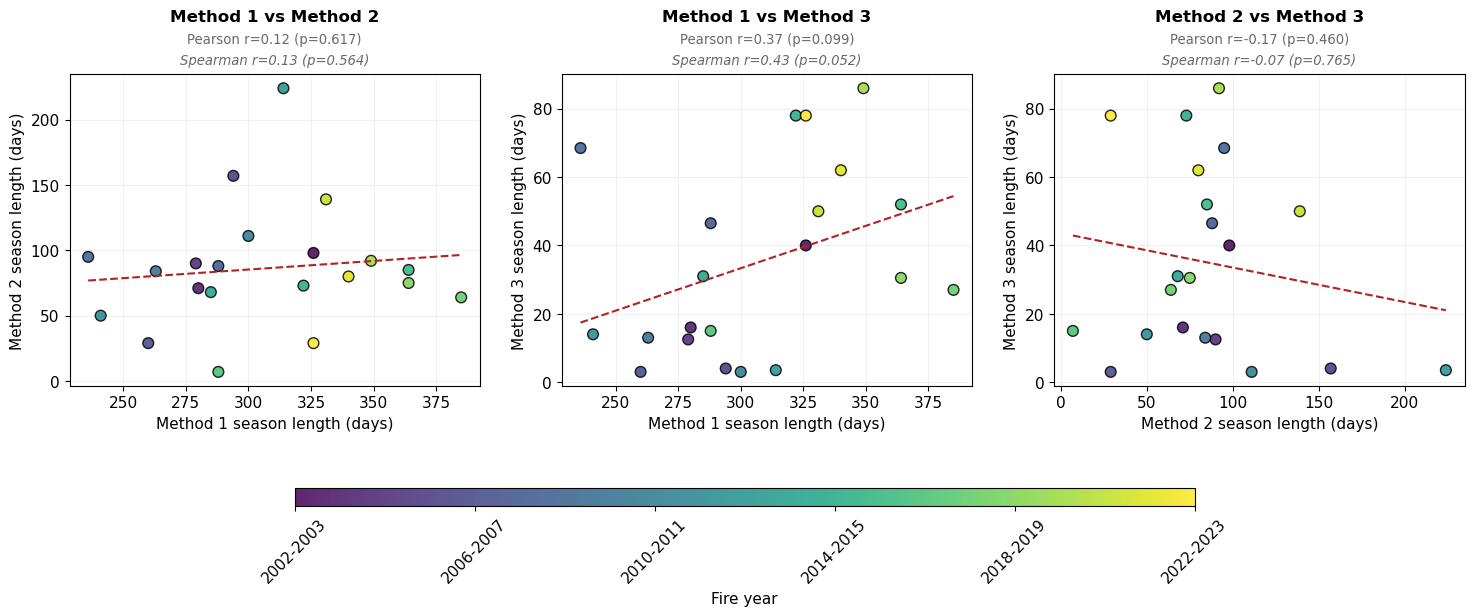

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
pairs = [
    ("method1_days", "method2_days", "Method 1", "Method 2"),
    ("method1_days", "method3_days", "Method 1", "Method 3"),
    ("method2_days", "method3_days", "Method 2", "Method 3"),
]
for ax, (col1, col2, name1, name2) in zip(axes, pairs):
    valid = comparison_df[[col1, col2, "fire_year"]].dropna()
    valid_idx = valid.index
    
    pearson_r, pearson_p = pearsonr(valid[col1], valid[col2])
    spearman_r, spearman_p = spearmanr(valid[col1], valid[col2])
    
    sc = ax.scatter(valid[col1], valid[col2], c=valid_idx, cmap="viridis", 
                     alpha=0.85, edgecolor="black", s=60)
    
    z = np.polyfit(valid[col1], valid[col2], 1)
    x_line = np.linspace(valid[col1].min(), valid[col1].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), color="firebrick", linestyle="--", linewidth=1.5)
    
    ax.set_xlabel(f"{name1} season length (days)")
    ax.set_ylabel(f"{name2} season length (days)")
    
    # bold main titles
    ax.set_title(f"{name1} vs {name2}", fontsize=12, fontweight="bold", pad=38)
    
    # stats lines subheadings
    ax.text(0.5, 1.10, f"Pearson r={pearson_r:.2f} (p={pearson_p:.3f})",
            transform=ax.transAxes, ha="center", fontsize=9.5, color="dimgrey")
    ax.text(0.5, 1.03, f"Spearman r={spearman_r:.2f} (p={spearman_p:.3f})",
            transform=ax.transAxes, ha="center", fontsize=9.5, color="dimgrey", style="italic")
    
    ax.grid(True, which='major', axis='both', color='grey', linestyle='-', linewidth=0.4, alpha=0.2)
    ax.set_axisbelow(True)  # ensures grid sits behind the data

# Reserve space at the bottom for the colorbar
fig.subplots_adjust(bottom=0.28, top=0.80)
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(sc, cax=cbar_ax, orientation="horizontal",
                     ticks=range(0, len(comparison_df), 4))
cbar.ax.set_xticklabels([comparison_df["fire_year"].iloc[i] for i in range(0, len(comparison_df), 4)], rotation=45)
cbar.set_label("Fire year")
plt.show()
fig.savefig("../outputs/fig7_fsl_pairwise_correlations.png", dpi=150, bbox_inches="tight")

## Studying the Minimum Lengths for Methods 2 and 3

In [13]:
print("Method 2 lowest seasons:")
print(comparison_df[["fire_year", "method2_days"]].sort_values("method2_days").head(5))

print("\nMethod 3 lowest seasons:")
print(comparison_df[["fire_year", "method3_days"]].sort_values("method3_days").head(5))

Method 2 lowest seasons:
    fire_year  method2_days
14  2016-2017             7
4   2006-2007            29
20  2022-2023            29
9   2011-2012            50
15  2017-2018            64

Method 3 lowest seasons:
    fire_year  method3_days
4   2006-2007           3.0
8   2010-2011           3.0
10  2012-2013           3.5
3   2005-2006           4.0
2   2004-2005          12.5


In [14]:
print("method2_df columns:", method2_df.columns.tolist())
print(method2_df.head())
print()
print("df_results columns:", df_results.columns.tolist())
print(df_results.head())

method2_df columns: ['file', 'fire_year_start', 'total_area_ha', 'p5_date', 'p95_date', 'season_length_days', 'fire_year', 'first_day', 'last_day']
                            file fire_year_start  total_area_ha  \
0  Base Datos IIFF 2018-2019.csv      2018-07-01     31093.2260   
1  Base Datos IIFF 2014-2015.csv      2014-07-01     81999.1191   
2  Base Datos IIFF 2016-2017.csv      2016-07-01    127770.2618   
3  Base Datos IIFF 2012-2013.csv      2012-07-01      5415.8659   
4  Base Datos IIFF 2008-2009.csv      2008-07-01     33302.2200   

              p5_date            p95_date  season_length_days  fire_year  \
0 2019-01-18 09:43:00 2019-04-03 15:56:00                  75  2018-2019   
1 2015-01-10 11:18:00 2015-03-25 04:40:00                  73  2014-2015   
2 2017-01-20 22:33:00 2017-01-28 10:00:00                   7  2016-2017   
3 2012-09-06 01:00:00 2013-04-18 17:50:00                 224  2012-2013   
4 2009-01-03 04:00:00 2009-04-08 14:43:00                  95  2008-2

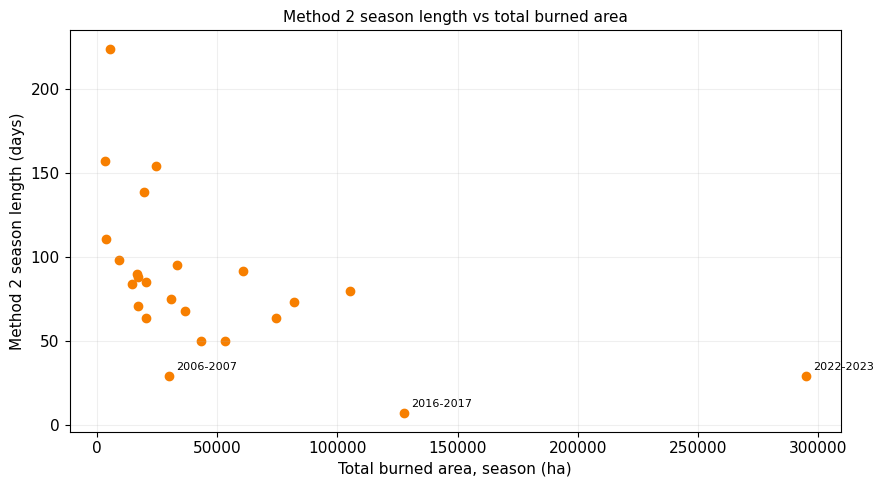

Spearman r=-0.683, p=0.0002


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(method2_df["total_area_ha"], method2_df["season_length_days"], color="#F77F00")
for _, row in method2_df.iterrows():
    if row["fire_year"] in ["2016-2017", "2006-2007", "2022-2023"]:
        ax.annotate(row["fire_year"], (row["total_area_ha"], row["season_length_days"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Total burned area, season (ha)")
ax.set_ylabel("Method 2 season length (days)")
ax.set_title("Method 2 season length vs total burned area")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

corr = stats.spearmanr(method2_df["total_area_ha"], method2_df["season_length_days"])
print(f"Spearman r={corr[0]:.3f}, p={corr[1]:.4f}")

In [16]:
print(method2_df[method2_df["fire_year"].isin(["2016-2017", "2022-2023"])]
      [["fire_year", "total_area_ha", "season_length_days", "p5_date", "p95_date"]])

print(f"\nMean total_area_ha across all seasons: {method2_df['total_area_ha'].mean():.0f}")
print(f"Median total_area_ha across all seasons: {method2_df['total_area_ha'].median():.0f}")

    fire_year  total_area_ha  season_length_days             p5_date  \
2   2016-2017    127770.2618                   7 2017-01-20 22:33:00   
12  2022-2023    294706.7930                  29 2023-01-19 11:20:00   

              p95_date  
2  2017-01-28 10:00:00  
12 2023-02-17 12:44:00  

Mean total_area_ha across all seasons: 47798
Median total_area_ha across all seasons: 27362


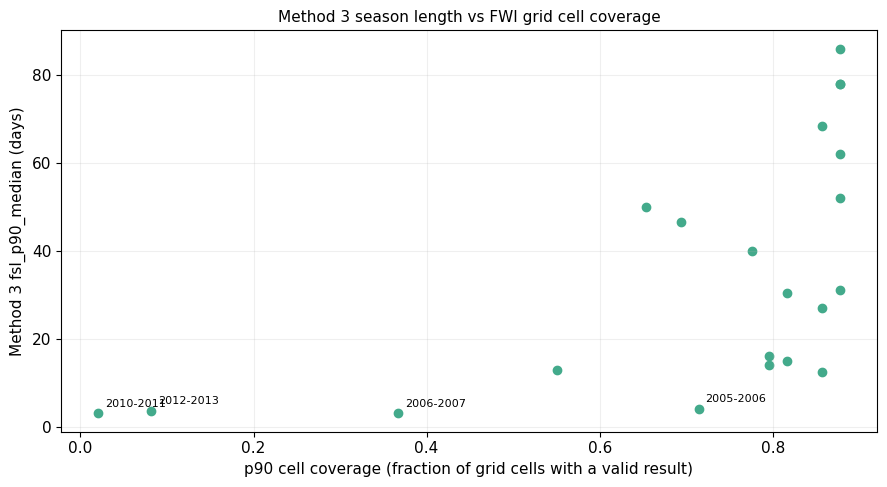

Spearman r=0.739, p=0.0001
           fsl_p90_median  p90_cell_coverage
fire_year                                   
2006-2007             3.0           0.367347
2010-2011             3.0           0.020408
2012-2013             3.5           0.081633
2005-2006             4.0           0.714286
2004-2005            12.5           0.857143
2009-2010            13.0           0.551020
2011-2012            14.0           0.795918
2016-2017            15.0           0.816327


In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df_results["p90_cell_coverage"], df_results["fsl_p90_median"], color="#43AA8B")
for year, row in df_results.iterrows():
    if year in ["2006-2007", "2010-2011", "2012-2013", "2005-2006"]:
        ax.annotate(year, (row["p90_cell_coverage"], row["fsl_p90_median"]),
                    textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("p90 cell coverage (fraction of grid cells with a valid result)")
ax.set_ylabel("Method 3 fsl_p90_median (days)")
ax.set_title("Method 3 season length vs FWI grid cell coverage")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

corr_m3 = stats.spearmanr(df_results["p90_cell_coverage"], df_results["fsl_p90_median"])
print(f"Spearman r={corr_m3[0]:.3f}, p={corr_m3[1]:.4f}")

print(df_results[["fsl_p90_median", "p90_cell_coverage"]].sort_values("fsl_p90_median").head(8))

In [18]:
coverage_threshold = 0.3  # years below this treated as data-limited rather than climate signal
low_coverage_years = df_results[df_results["p90_cell_coverage"] < coverage_threshold]
adequate_coverage = df_results[df_results["p90_cell_coverage"] >= coverage_threshold]

print(f"Years below {coverage_threshold} coverage (n={len(low_coverage_years)}):")
print(low_coverage_years[["fsl_p90_median", "p90_cell_coverage"]])

print(f"\nSpearman r on adequate-coverage years only (n={len(adequate_coverage)}):")
corr_adequate = stats.spearmanr(adequate_coverage["p90_cell_coverage"], adequate_coverage["fsl_p90_median"])
print(f"r={corr_adequate[0]:.3f}, p={corr_adequate[1]:.4f}")

Years below 0.3 coverage (n=2):
           fsl_p90_median  p90_cell_coverage
fire_year                                   
2010-2011             3.0           0.020408
2012-2013             3.5           0.081633

Spearman r on adequate-coverage years only (n=19):
r=0.649, p=0.0026


In [19]:
print(df_results[["fsl_p90_median", "p90_cell_coverage", "start_doy_p90", "end_doy_p90"]]
      .sort_values("fsl_p90_median").head(8))

           fsl_p90_median  p90_cell_coverage  start_doy_p90  end_doy_p90
fire_year                                                               
2006-2007             3.0           0.367347          196.0        208.5
2010-2011             3.0           0.020408          219.0        221.0
2012-2013             3.5           0.081633          207.5        210.0
2005-2006             4.0           0.714286          223.0        227.0
2004-2005            12.5           0.857143          201.0        241.0
2009-2010            13.0           0.551020          205.0        216.0
2011-2012            14.0           0.795918          185.0        216.0
2016-2017            15.0           0.816327          204.0        217.0


In [20]:
# Method 3 season classification table
# Tiers years by p90_cell_coverage to distinguish coverage-limited
# estimates from genuinely short/fragmented fire-weather seasons

df_m3_classified = df_results.reset_index().copy()

df_m3_classified["doy_gap_p90"] = df_m3_classified["end_doy_p90"] - df_m3_classified["start_doy_p90"]

def classify_coverage(coverage):
    if coverage < 0.10:
        return "Low-confidence (coverage-limited)"
    elif coverage < 0.40:
        return "Fragmented season (low-moderate coverage)"
    else:
        return "Adequate coverage"

df_m3_classified["coverage_tier"] = df_m3_classified["p90_cell_coverage"].apply(classify_coverage)

m3_summary_table = df_m3_classified[
    ["fire_year", "fsl_p90_median", "p90_cell_coverage", "doy_gap_p90", "coverage_tier"]
].sort_values("fsl_p90_median").reset_index(drop=True)

m3_summary_table = m3_summary_table.rename(columns={
    "fire_year": "Fire year",
    "fsl_p90_median": "Method 3 season length (days)",
    "p90_cell_coverage": "p90 cell coverage (fraction)",
    "doy_gap_p90": "Region-wide DOY span (days)",
    "coverage_tier": "Classification"
})

print(m3_summary_table.to_string(index=False))

m3_summary_table.to_csv("../outputs/method3_coverage_classification.csv", index=False)

# Quick tier-level summary stats
tier_counts = df_m3_classified["coverage_tier"].value_counts()
print("\nSeasons per tier:")
print(tier_counts)

print("\nMean fsl_p90_median by tier:")
print(df_m3_classified.groupby("coverage_tier")["fsl_p90_median"].agg(["mean", "min", "max", "count"]))

Fire year  Method 3 season length (days)  p90 cell coverage (fraction)  Region-wide DOY span (days)                            Classification
2006-2007                            3.0                      0.367347                         12.5 Fragmented season (low-moderate coverage)
2010-2011                            3.0                      0.020408                          2.0         Low-confidence (coverage-limited)
2012-2013                            3.5                      0.081633                          2.5         Low-confidence (coverage-limited)
2005-2006                            4.0                      0.714286                          4.0                         Adequate coverage
2004-2005                           12.5                      0.857143                         40.0                         Adequate coverage
2009-2010                           13.0                      0.551020                         11.0                         Adequate coverage
2011-2